   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   South  FUR-BO-10

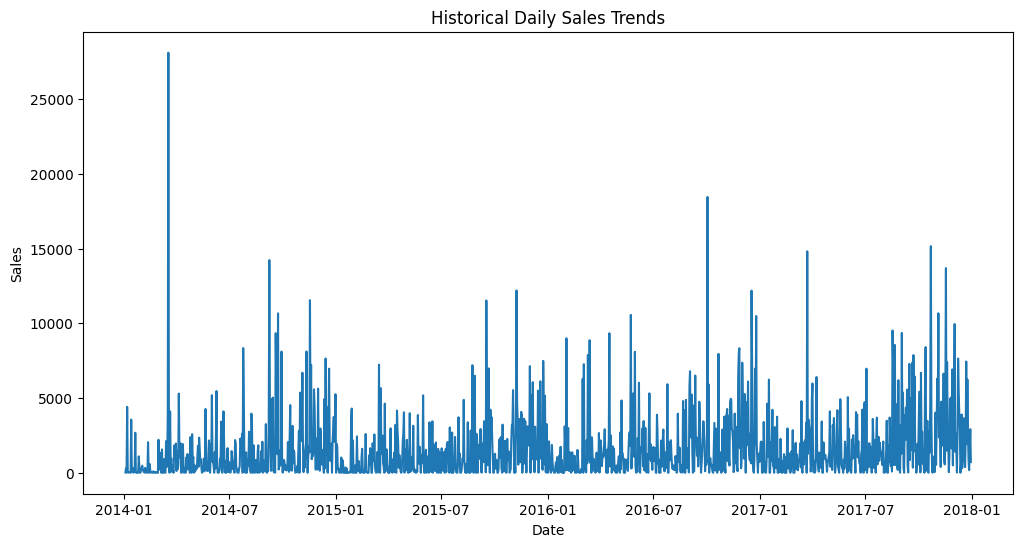

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import os

os.makedirs("data", exist_ok=True)
os.makedirs("visuals", exist_ok=True)


# Load data
df = pd.read_csv(
    r'D:\Future intern\FUTURE_ML_01\Sample - Superstore.csv',
    encoding="latin1"
)

# Function to convert mixed dates
def convert_date(x):
    try:
        if isinstance(x, (int, float)):
            return pd.to_datetime(x, origin='1899-12-30', unit='D')
        else:
            return pd.to_datetime(x)
    except:
        return pd.NaT  # Not a Time

df['Order Date'] = df['Order Date'].apply(convert_date)
df['Ship Date'] = df['Ship Date'].apply(convert_date)

# Drop invalid dates (if any)
df = df.dropna(subset=['Order Date'])

# Inspect
print(df.head())
print(df.info())
print(df.describe())
print('Date range:', df['Order Date'].min(), 'to', df['Order Date'].max())

# Handle other cleaning: Ensure Sales is float, no duplicates
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')
df = df.drop_duplicates()

# Aggregate to daily sales for time series
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()
daily_sales.columns = ['ds', 'y']  # Prophet: ds=date, y=value
daily_sales = daily_sales.sort_values('ds')

# Fill missing dates with 0 sales (important for Prophet)
date_range = pd.date_range(start=daily_sales['ds'].min(), end=daily_sales['ds'].max(), freq='D')
daily_sales = daily_sales.set_index('ds').reindex(date_range, fill_value=0).reset_index()
daily_sales.columns = ['ds', 'y']

# Save cleaned data
daily_sales.to_csv('data/cleaned_daily_sales.csv', index=False)
df.to_csv('data/cleaned_full_data.csv', index=False)  # For Power BI filters

# Quick plot: Historical trends
plt.figure(figsize=(12, 6))
sns.lineplot(x='ds', y='y', data=daily_sales)
plt.title('Historical Daily Sales Trends')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.savefig('visuals/historical_trends.png')
plt.show()

In [9]:
from datetime import datetime

# Add to daily_sales
daily_sales['month'] = daily_sales['ds'].dt.month
daily_sales['quarter'] = daily_sales['ds'].dt.quarter
daily_sales['year'] = daily_sales['ds'].dt.year
daily_sales['day_of_week'] = daily_sales['ds'].dt.dayofweek
daily_sales['is_weekend'] = daily_sales['day_of_week'].isin([5, 6]).astype(int)  # Potential regressor

# Monthly averages for insights (e.g., highlight low seasons)
monthly_avg = daily_sales.groupby('month')['y'].mean().reset_index()
print('Monthly Avg Sales:\n', monthly_avg)
monthly_avg.to_csv('data/monthly_averages.csv', index=False)

# Holidays as dataframe for Prophet (add more US holidays)
holidays = pd.DataFrame({
    'holiday': 'holiday',
    'ds': pd.to_datetime([
        '2014-01-01', '2014-07-04', '2014-12-25',  # 2014 examples
        '2015-01-01', '2015-07-04', '2015-12-25',
        '2016-01-01', '2016-07-04', '2016-12-25',
        '2017-01-01', '2017-07-04', '2017-12-25'
    ]),
    'lower_window': 0,
    'upper_window': 1  # Effect on day and next
})

# For dashboard: Prep category/region sales (export for Power BI)
category_sales = df.groupby(['Order Date', 'Category'])['Sales'].sum().reset_index()
category_sales.to_csv('data/category_sales.csv', index=False)

region_sales = df.groupby(['Order Date', 'Region'])['Sales'].sum().reset_index()
region_sales.to_csv('data/region_sales.csv', index=False)





Monthly Avg Sales:
     month            y
0       1   778.072423
1       2   528.772136
2       3  1653.270071
3       4  1148.017738
4       5  1250.232352
5       6  1272.655661
6       7  1187.404008
7       8  1282.613411
8       9  2563.749548
9      10  1615.507941
10     11  2937.175592
11     12  2644.662630


15:10:39 - cmdstanpy - INFO - Chain [1] start processing
15:10:39 - cmdstanpy - INFO - Chain [1] done processing
15:10:41 - cmdstanpy - INFO - Chain [1] start processing
15:10:42 - cmdstanpy - INFO - Chain [1] done processing


MAE: 1656.4
Avg daily sales: 1575.58
MAE %: 105.13 %


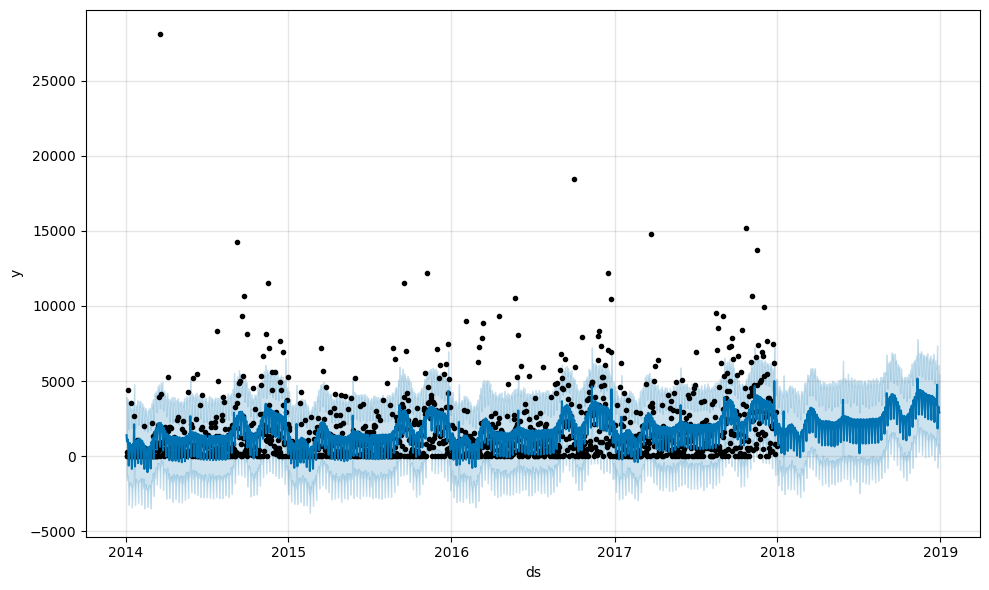

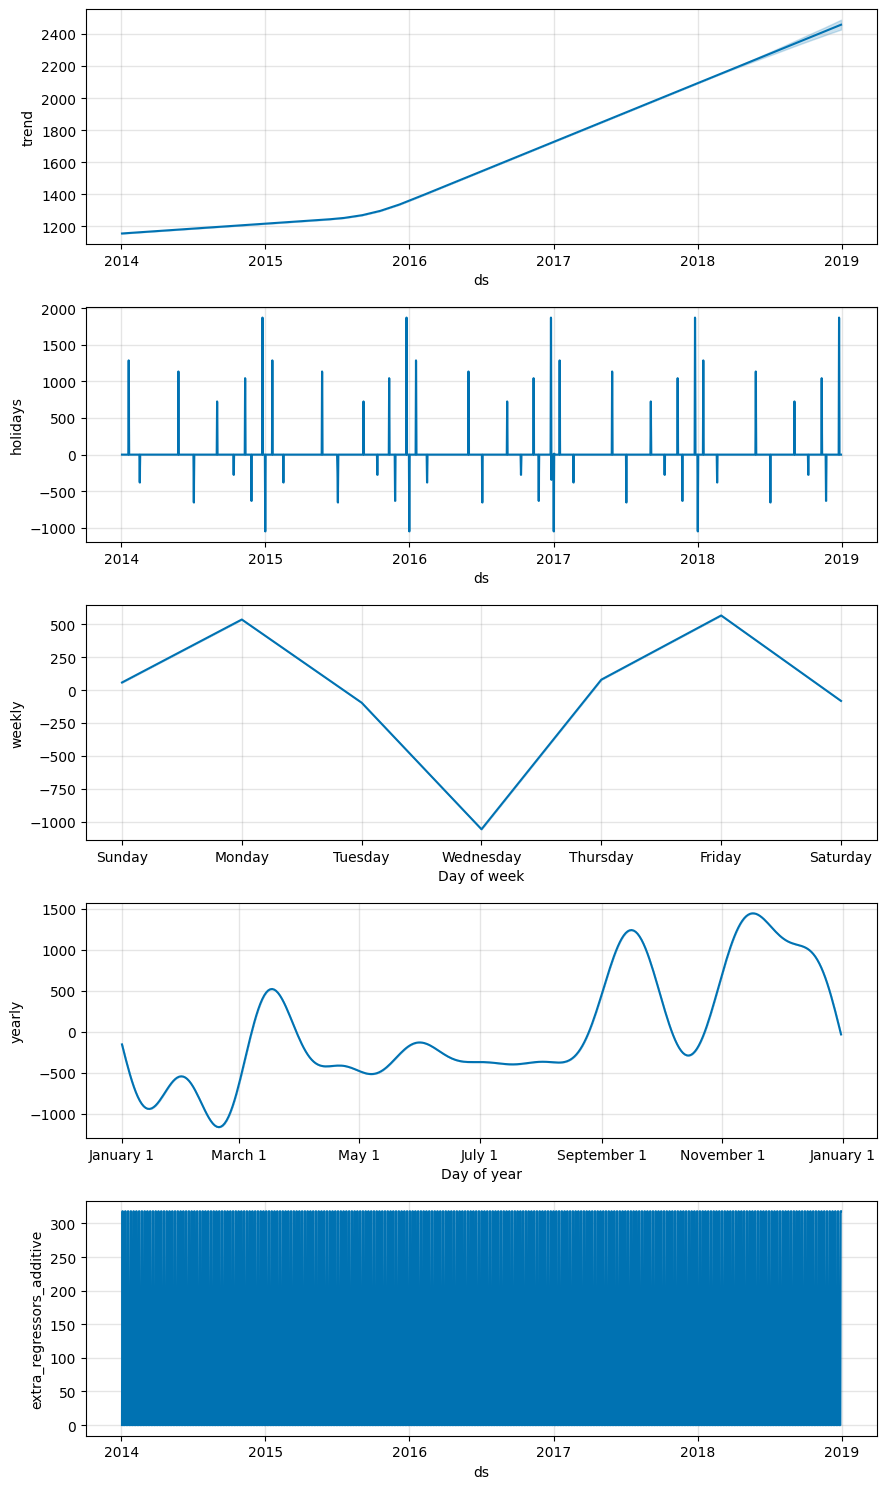

In [14]:
from prophet import Prophet
import pandas as pd

# Ensure correct columns
daily_sales = daily_sales[['ds', 'y', 'is_weekend']]
daily_sales['ds'] = pd.to_datetime(daily_sales['ds'])

# -------------------------
# TRAIN MAIN MODEL
# -------------------------
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model.add_country_holidays(country_name='US')
model.add_regressor('is_weekend')

model.fit(daily_sales)

# -------------------------
# FUTURE FORECAST
# -------------------------
future = model.make_future_dataframe(periods=365)
future['is_weekend'] = future['ds'].dt.dayofweek.isin([5,6]).astype(int)

forecast = model.predict(future)

# Save forecast
forecast[['ds','yhat','yhat_lower','yhat_upper','trend']].to_csv('data/forecast.csv', index=False)

# Plots
fig1 = model.plot(forecast)
plt.savefig('visuals/forecast_plot.png')

fig2 = model.plot_components(forecast)
plt.savefig('visuals/forecast_components.png')

# -------------------------
# MODEL EVALUATION
# -------------------------
train_size = int(len(daily_sales) * 0.8)
train = daily_sales.iloc[:train_size]
test = daily_sales.iloc[train_size:]

model_eval = Prophet(yearly_seasonality=True, weekly_seasonality=True)
model_eval.add_country_holidays(country_name='US')
model_eval.add_regressor('is_weekend')

model_eval.fit(train)

future_test = model_eval.make_future_dataframe(periods=len(test))
future_test['is_weekend'] = future_test['ds'].dt.dayofweek.isin([5,6]).astype(int)

forecast_test = model_eval.predict(future_test)

predictions = forecast_test.iloc[-len(test):]['yhat']

from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(test['y'], predictions)

print("MAE:", round(mae,2))
print("Avg daily sales:", round(daily_sales['y'].mean(),2))
print("MAE %:", round(mae / daily_sales['y'].mean() * 100, 2), "%")


In [15]:
top_items = (
    df.groupby('Product Name')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

top_items.columns = ['Product Name','Total Sales']
top_items.to_csv('data/top_items.csv', index=False)


In [17]:
category_sales = df.groupby(['Order Date','Category'])['Sales'].sum().reset_index()
category_sales.to_csv('data/category_sales.csv', index=False)
